<a href="https://colab.research.google.com/github/Ayush28-ai/Ayush28-ai/blob/main/Pet_Emotion_Detection_2_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] =  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] =  # Replace with your Kaggle API key

# Install Kaggle CLI
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d anshtanwar/pets-facial-expression-dataset

# Unzip the dataset
!unzip -q /content/pets-facial-expression-dataset.zip -d data

Dataset URL: https://www.kaggle.com/datasets/anshtanwar/pets-facial-expression-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/38.6M [00:00<?, ?B/s]
100% 38.6M/38.6M [00:00<00:00, 1.01GB/s]


In [ ]:
import os
import shutil
import random

# Paths
SOURCE_DIR = "/content/data"               # parent containing 4 class folders
DEST_DIR = "/content/split_data"           # new output directory

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
random.seed(42)

# Get class folders (ignore Master Folder)
classes = [d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d)) and d != "Master Folder"]
print("Classes found:", classes)

# Create folder structure
for split in ["train", "valid", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

# Split files per class
for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = images[:n_train]
    val_files = images[n_train:n_train + n_val]
    test_files = images[n_train + n_val:]

    print(f"{cls}: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

    for file_list, split in [(train_files, "train"), (val_files, "valid"), (test_files, "test")]:
        for img in file_list:
            src = os.path.join(cls_path, img)
            dst = os.path.join(DEST_DIR, split, cls, img)
            shutil.copy2(src, dst)

print("\n Done! Dataset split into:")
print(f"{DEST_DIR}/train/, {DEST_DIR}/valid/, and {DEST_DIR}/test/")


Classes found: ['happy', 'Sad', 'Other', 'Angry']
happy: Train=175, Val=37, Test=38
Sad: Train=175, Val=37, Test=38
Other: Train=175, Val=37, Test=38
Angry: Train=175, Val=37, Test=38

 Done! Dataset split into:
/content/split_data/train/, /content/split_data/valid/, and /content/split_data/test/


In [ ]:
train_data_dir = '/content/split_data/train'
valid_data_dir = '/content/split_data/valid'
test_data_dir  = '/content/split_data/test'

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training, light preprocessing for validation/testing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print("Detected classes:", train_gen.class_indices)


Found 700 images belonging to 4 classes.
Found 148 images belonging to 4 classes.
Found 152 images belonging to 4 classes.
Detected classes: {'Angry': 0, 'Other': 1, 'Sad': 2, 'happy': 3}


In [ ]:
import cv2
from skimage.feature import local_binary_pattern

def extract_lbp_gabor(img):
    img = cv2.resize(img, (224, 224))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # LBP
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp = cv2.normalize(lbp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Gabor filters (multi-orientation)
    gabor_sum = np.zeros_like(gray, dtype=np.float32)
    for theta in range(4):
        kernel = cv2.getGaborKernel((9, 9), 4.0, np.pi/4 * theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
        fimg = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
        gabor_sum += fimg.astype(np.float32)
    gabor_sum = cv2.normalize(gabor_sum, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Merge to 3-channel representation
    combined = cv2.merge((gray, lbp, gabor_sum))
    combined = combined / 255.0
    return combined


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Model

# Feature extractor
feature_extractor = MobileNetV2(include_top=False, weights='imagenet', pooling='avg')
feature_extractor.trainable = False  # freeze

inputs = Input(shape=(224, 224, 3))
x = feature_extractor(inputs, training=False)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


/tmp/ipython-input-3496280223.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  feature_extractor = MobileNetV2(include_top=False, weights='imagenet', pooling='avg')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features.flatten()


In [ ]:
import os

features = []
labels = []

for label in ['Angry','Other','Sad','happy']:
    folder = f'/content/split_data/train/{label}'
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        feat = extract_features(img_path, model)
        features.append(feat)
        labels.append(label)

features = np.array(features)
labels = np.array(labels)


In [ ]:
features = np.array(features)
labels = np.array(labels)
print("Feature shape:", features.shape)

Feature shape: (700, 4)


In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

IMG_SIZE = (224, 224)

# Load ResNet50 without top layers, pooling='avg' to get feature vectors
resnet = MobileNetV2(include_top=False, weights='imagenet', pooling='avg')

def extract_features_from_folder(base_folder):
    features, labels = [], []
    for label in os.listdir(base_folder):
        folder = os.path.join(base_folder, label)
        if not os.path.isdir(folder):
            continue
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            feat = resnet.predict(img_array, verbose=0)
            features.append(feat.flatten())
            labels.append(label)
    return np.array(features), np.array(labels)

# Extract features
X_train, y_train = extract_features_from_folder('/content/split_data/train')
X_val, y_val = extract_features_from_folder('/content/split_data/valid')
X_test, y_test = extract_features_from_folder('/content/split_data/test')

# Encode labels
le = LabelEncoder()
y_train = to_categorical(le.fit_transform(y_train))
y_val   = to_categorical(le.transform(y_val))
y_test  = to_categorical(le.transform(y_test))

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)



/tmp/ipython-input-3454204956.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  resnet = MobileNetV2(include_top=False, weights='imagenet', pooling='avg')


Train: (703, 1280) Val: (159, 1280) Test: (156, 1280)


In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==========================================================
# STEP 2: CLASSIFICATION USING EFFICIENTNET-LIKE DENSE HEAD
# ==========================================================

# You can't directly use EfficientNetB0 here because its input expects images (224x224x3)
# Instead, we build a custom fully connected classifier trained on the features extracted above.

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

NUM_CLASSES = y_train.shape[1]

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

# ==========================================================
# 🔹 STEP 3: EVALUATION
# ==========================================================
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

# Final test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Optional: Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2723 - loss: 2.0557 - val_accuracy: 0.3711 - val_loss: 1.2861
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4264 - loss: 1.5534 - val_accuracy: 0.4465 - val_loss: 1.2243
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5478 - loss: 1.2264 - val_accuracy: 0.5472 - val_loss: 1.1310
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6454 - loss: 0.9885 - val_accuracy: 0.5597 - val_loss: 1.0764
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6378 - loss: 0.8971 - val_accuracy: 0.5849 - val_loss: 1.0088
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6740 - loss: 0.8311 - val_accuracy: 0.6289 - val_loss: 0.9542
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7494 - loss: 0.6484 - val_accuracy: 0.6667 - val_loss: 0.9051
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7586 - loss: 0.6362 - val_accuracy: 0.6667 - val_loss: 0.

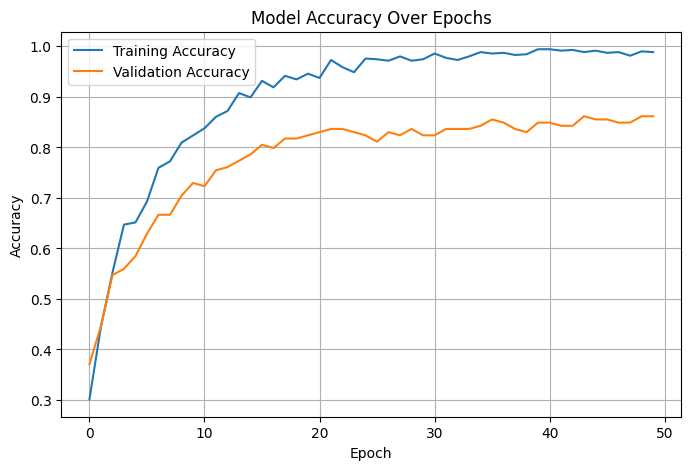

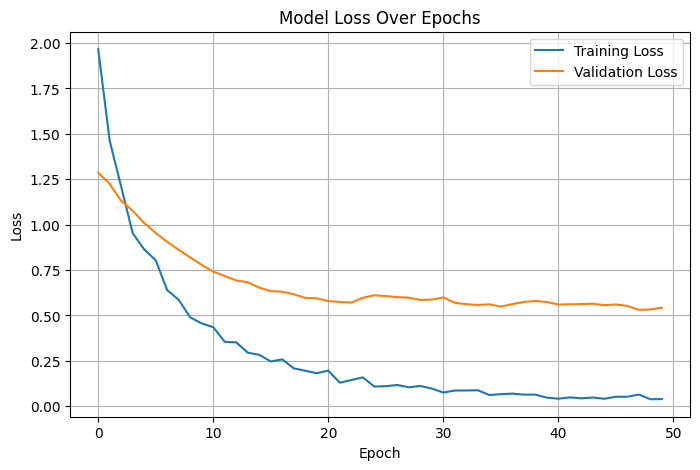

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Resnet

In [ ]:
import shutil
import os

master_folder = '/content/data/Master Folder'

# Check if it exists
if os.path.exists(master_folder):
    # Delete the folder and all its contents
    shutil.rmtree(master_folder)
    print("Master Folder deleted successfully!")
else:
    print("Master Folder does not exist.")


Master Folder deleted successfully!


In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

IMG_SIZE = (224, 224)

# Load ResNet50 without top layers, pooling='avg' to get feature vectors
resnet = ResNet50(include_top=False, weights='imagenet', pooling='avg')

def extract_features_from_folder(base_folder):
    features, labels = [], []
    for label in os.listdir(base_folder):
        folder = os.path.join(base_folder, label)
        if not os.path.isdir(folder):
            continue
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            feat = resnet.predict(img_array, verbose=0)
            features.append(feat.flatten())
            labels.append(label)
    return np.array(features), np.array(labels)

# Extract features
X_train, y_train = extract_features_from_folder('/content/split_data/train')
X_val, y_val = extract_features_from_folder('/content/split_data/valid')
X_test, y_test = extract_features_from_folder('/content/split_data/test')

# Encode labels
le = LabelEncoder()
y_train = to_categorical(le.fit_transform(y_train))
y_val   = to_categorical(le.transform(y_val))
y_test  = to_categorical(le.transform(y_test))

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (703, 2048) Val: (159, 2048) Test: (156, 2048)


In [ ]:
# ==========================================================
# STEP 2: CLASSIFICATION USING EFFICIENTNET-LIKE DENSE HEAD
# ==========================================================

# You can't directly use EfficientNetB0 here because its input expects images (224x224x3)
# Instead, we build a custom fully connected classifier trained on the features extracted above.

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

NUM_CLASSES = y_train.shape[1]

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

# ==========================================================
# 🔹 STEP 3: EVALUATION
# ==========================================================
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

# Final test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Optional: Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3032 - loss: 2.0186 - val_accuracy: 0.4151 - val_loss: 1.4475
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4678 - loss: 1.3773 - val_accuracy: 0.5031 - val_loss: 1.2248
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5960 - loss: 0.9873 - val_accuracy: 0.5849 - val_loss: 1.0771
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6877 - loss: 0.8223 - val_accuracy: 0.6667 - val_loss: 0.9270
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7294 - loss: 0.6930 - val_accuracy: 0.6855 - val_loss: 0.8260
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7980 - loss: 0.5541 - val_accuracy: 0.7233 - val_loss: 0.7516
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7892 - loss: 0.5584 - val_accuracy: 0.7296 - val_loss: 0.6906
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8356 - loss: 0.4325 - val_accuracy: 0.7610 - val_loss: 0.

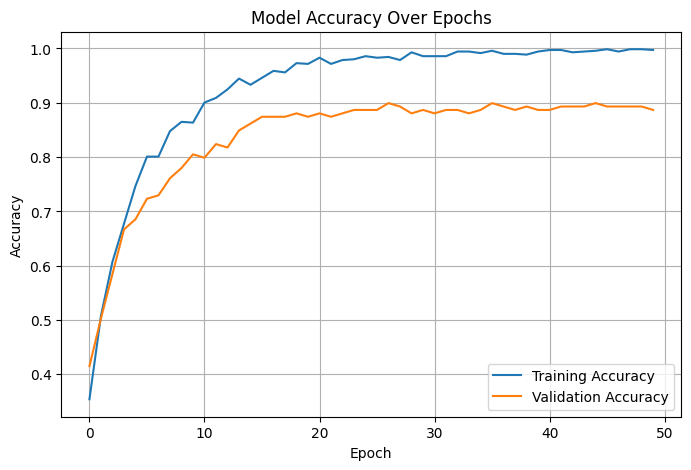

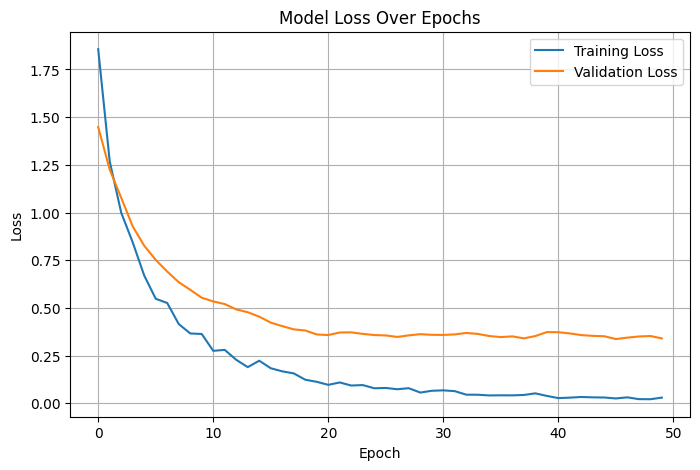

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# VGG

In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# -----------------------------
IMG_SIZE = (224, 224)
vgg_model = VGG16(include_top=False, weights='imagenet', pooling='avg')  # Global Average Pooling

# -----------------------------
def extract_features_from_folder(base_folder):
    features, labels = [], []
    for label in os.listdir(base_folder):
        folder = os.path.join(base_folder, label)
        if not os.path.isdir(folder):
            continue
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            feat = vgg_model.predict(img_array, verbose=0)
            features.append(feat.flatten())
            labels.append(label)
    return np.array(features), np.array(labels)

# -----------------------------
# Extract features separately for train, val, test
X_train, y_train = extract_features_from_folder('/content/split_data/train')
X_val, y_val     = extract_features_from_folder('/content/split_data/valid')
X_test, y_test   = extract_features_from_folder('/content/split_data/test')

# -----------------------------
# Encode labels
le = LabelEncoder()
y_train = to_categorical(le.fit_transform(y_train))
y_val   = to_categorical(le.transform(y_val))
y_test  = to_categorical(le.transform(y_test))

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (703, 512) Val: (159, 512) Test: (156, 512)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.2596 - loss: 2.0522 - val_accuracy: 0.4088 - val_loss: 1.8408
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3830 - loss: 1.5914 - val_accuracy: 0.4340 - val_loss: 1.4846
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4750 - loss: 1.4778 - val_accuracy: 0.5031 - val_loss: 1.2441
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5028 - loss: 1.3019 - val_accuracy: 0.5157 - val_loss: 1.1261
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5584 - loss: 1.1611 - val_accuracy: 0.5723 - val_loss: 1.0271
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5744 - loss: 1.0778 - val_accuracy: 0.6164 - val_loss: 0.9623
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6280 - loss: 0.8756 - val_accuracy: 0.6541 - val_loss: 0.9009
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6730 - loss: 0.8114 - val_accuracy: 0.6855 - val_loss: 0.

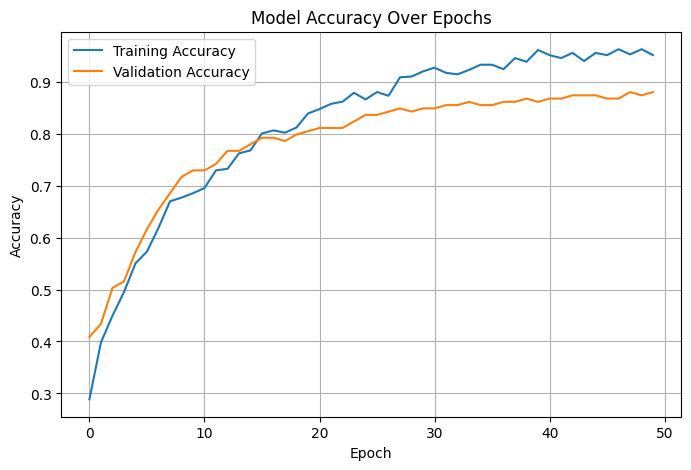

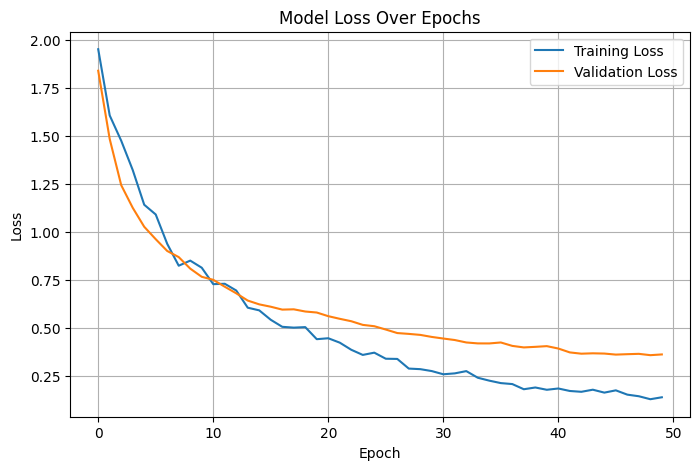

In [ ]:
# ==========================================================
# STEP 2: CLASSIFICATION USING EFFICIENTNET-LIKE DENSE HEAD
# ==========================================================

# You can't directly use EfficientNetB0 here because its input expects images (224x224x3)
# Instead, we build a custom fully connected classifier trained on the features extracted above.

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

NUM_CLASSES = y_train.shape[1]

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

# ==========================================================
# 🔹 STEP 3: EVALUATION
# ==========================================================
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

# Final test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Optional: Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import os

root_folder = '/content/split_data'  # your dataset root
subsets = ['train', 'valid', 'test']
image_extensions = ('.jpg', '.jpeg', '.png')

for subset in subsets:
    subset_path = os.path.join(root_folder, subset)
    count = 0
    print(f"\n{subset.upper()}:")
    for class_name in os.listdir(subset_path):
        class_folder = os.path.join(subset_path, class_name)
        if not os.path.isdir(class_folder):
            continue
        num_images = len([f for f in os.listdir(class_folder) if f.lower().endswith(image_extensions)])
        print(f"  {class_name}: {num_images} images")
        count += num_images
    print(f"  Total images in {subset}: {count}")



TRAIN:
  happy: 176 images
  Sad: 176 images
  Other: 176 images
  Angry: 175 images
  Total images in train: 703

VALID:
  happy: 43 images
  Sad: 42 images
  Other: 37 images
  Angry: 37 images
  Total images in valid: 159

TEST:
  happy: 40 images
  Sad: 40 images
  Other: 38 images
  Angry: 38 images
  Total images in test: 156


# resnet + class weights - model final

In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

IMG_SIZE = (224, 224)

# Load ResNet50 without top layers, pooling='avg' to get feature vectors
resnet = ResNet50(include_top=False, weights='imagenet', pooling='avg')

def extract_features_from_folder(base_folder):
    features, labels = [], []
    for label in os.listdir(base_folder):
        folder = os.path.join(base_folder, label)
        if not os.path.isdir(folder):
            continue
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            feat = resnet.predict(img_array, verbose=0)
            features.append(feat.flatten())
            labels.append(label)
    return np.array(features), np.array(labels)

# Extract features
X_train, y_train = extract_features_from_folder('/content/split_data/train')
X_val, y_val = extract_features_from_folder('/content/split_data/valid')
X_test, y_test = extract_features_from_folder('/content/split_data/test')

# Encode labels
le = LabelEncoder()
y_train = to_categorical(le.fit_transform(y_train))
y_val   = to_categorical(le.transform(y_val))
y_test  = to_categorical(le.transform(y_test))

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (703, 2048) Val: (159, 2048) Test: (156, 2048)


Class weights: {np.int64(0): np.float64(1.0042857142857142), np.int64(1): np.float64(0.9985795454545454), np.int64(2): np.float64(0.9985795454545454), np.int64(3): np.float64(0.9985795454545454)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.2979 - loss: 1.9233 - val_accuracy: 0.4465 - val_loss: 1.2591
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4871 - loss: 1.4630 - val_accuracy: 0.5283 - val_loss: 1.0786
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5936 - loss: 1.0383 - val_accuracy: 0.5912 - val_loss: 1.0069
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6446 - loss: 0.8659 - val_accuracy: 0.6478 - val_loss: 0.9404
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6990 - loss: 0.7299 - val_accuracy: 0.6604 - val_loss: 0.8761
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7674 - loss: 0.6687 - val_accuracy: 0.7044 - val_loss: 0.8152
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8009 - loss: 0.5488 - val_accuracy: 0.7484 - val_loss: 0.7502
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8251 - loss: 0.4552 - val_accuracy: 0.7547 - val_loss: 0.

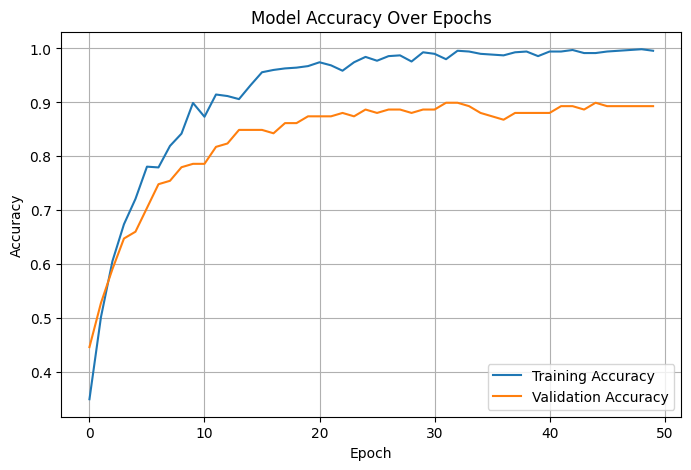

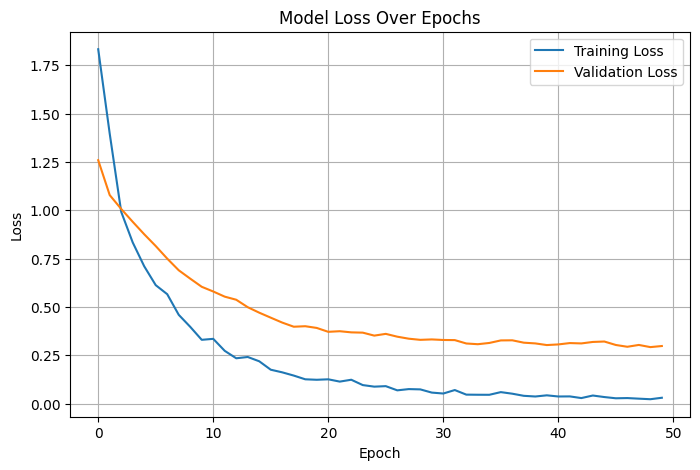

In [ ]:
# ==========================================================
# STEP 2: CLASSIFICATION USING EFFICIENTNET-LIKE DENSE HEAD
# ==========================================================

# You can't directly use EfficientNetB0 here because its input expects images (224x224x3)
# Instead, we build a custom fully connected classifier trained on the features extracted above.

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

NUM_CLASSES = y_train.shape[1]
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert one-hot y_train to integer labels
y_train_integers = np.argmax(y_train, axis=1)

# Compute class weights from training labels
classes = np.unique(y_train_integers)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_integers)

# Convert to dictionary for Keras
class_weights_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weights_dict)


model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=32,
                    class_weight=class_weights_dict,
                    verbose=1)

# ==========================================================
# 🔹 STEP 3: EVALUATION
# ==========================================================
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

# Final test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Optional: Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


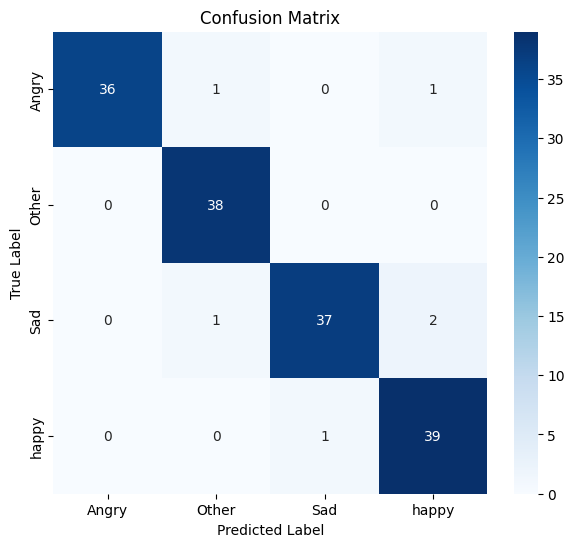

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
classes = le.classes_  # ['Angry', 'Other', 'Sad', 'happy']

# Plot confusion matrix
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Save the model
model.save('ResNet_Feature_Classifier.h5')
print("Model saved as ResNet_Feature_Classifier.h5")


Model saved as ResNet_Feature_Classifier.h5


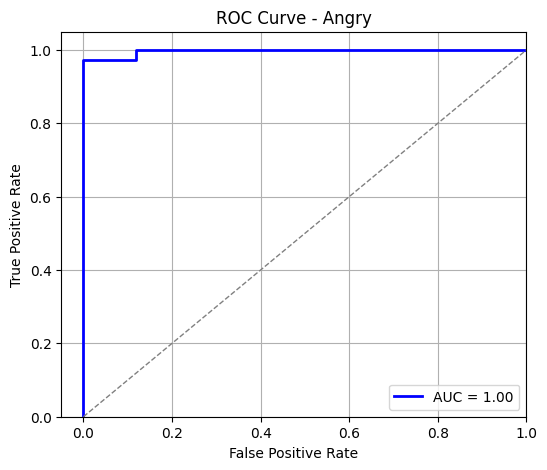

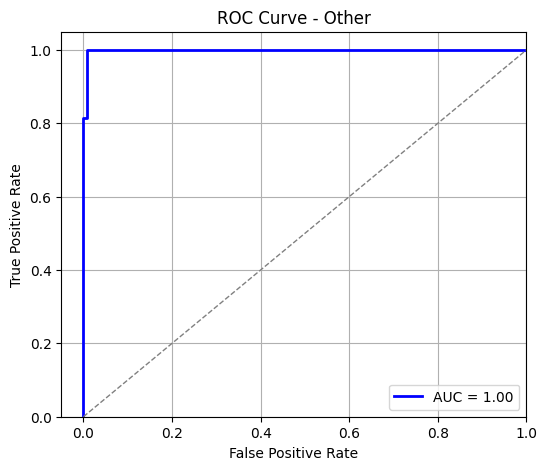

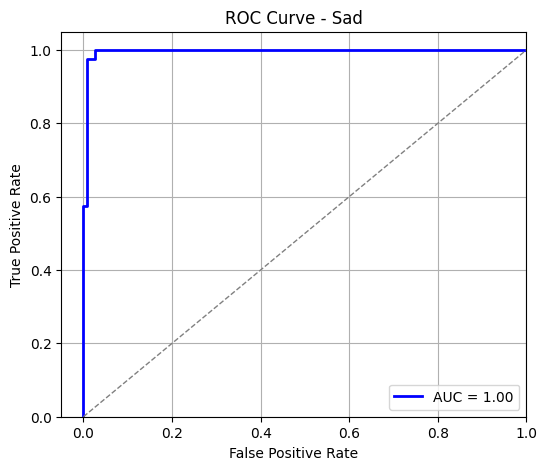

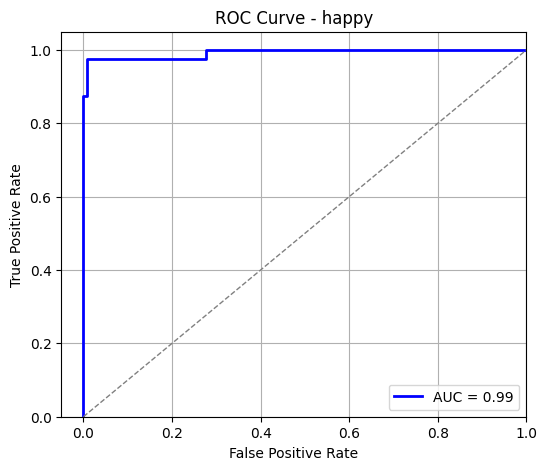

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test is one-hot encoded
n_classes = y_test.shape[1]

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
    plt.xlim([-0.05, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {le.classes_[i]}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


# Generalization

In [ ]:
import os

# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = 'codingpanda5'  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = '0c87ee462cdc408e405cd4f933c41ef0' # Replace with your Kaggle API key

# Install Kaggle CLI
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d danielshanbalico/dog-emotion

Dataset URL: https://www.kaggle.com/datasets/danielshanbalico/dog-emotion
License(s): CC0-1.0
100% 155M/155M [00:00<00:00, 1.62GB/s]
100% 155M/155M [00:00<00:00, 1.62GB/s]


In [ ]:
!unzip -q /content/dog-emotion.zip

In [ ]:
import os
import shutil

source_folder = '/content/Dog Emotion'
dest_folder = '/content/dog_emotion_cleaned'

os.makedirs(dest_folder, exist_ok=True)

# Define new class mapping
class_map = {
    'angry': 'Angry',
    'sad': 'Sad',
    'happy': 'happy',
    'relaxed': 'Other'
}

for old_class, new_class in class_map.items():
    old_path = os.path.join(source_folder, old_class)
    new_path = os.path.join(dest_folder, new_class)
    os.makedirs(new_path, exist_ok=True)

    for img_name in os.listdir(old_path):
        src_img = os.path.join(old_path, img_name)
        dst_img = os.path.join(new_path, img_name)
        shutil.copy(src_img, dst_img)

print("Dataset cleaned and classes remapped successfully!")


Dataset cleaned and classes remapped successfully!


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import os

IMG_SIZE = (224, 224)
resnet = ResNet50(include_top=False, weights='imagenet', pooling='avg')

def extract_features_from_folder(base_folder):
    features, labels = [], []
    for label in os.listdir(base_folder):
        folder = os.path.join(base_folder, label)
        if not os.path.isdir(folder):
            continue
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            feat = resnet.predict(img_array, verbose=0)
            features.append(feat.flatten())
            labels.append(label)
    return np.array(features), np.array(labels)

X_ext, y_ext = extract_features_from_folder('/content/dog_emotion_cleaned')

le = LabelEncoder()
y_ext_enc = to_categorical(le.fit_transform(y_ext))

print("Features shape:", X_ext.shape)
print("Labels shape:", y_ext_enc.shape)


Features shape: (4000, 2048)
Labels shape: (4000, 4)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:

              precision    recall  f1-score   support

       Angry       0.35      0.11      0.17      1000
       Other       0.34      0.15      0.21      1000
         Sad       0.44      0.41      0.42      1000
       happy       0.33      0.75      0.46      1000

    accuracy                           0.36      4000
   macro avg       0.36      0.36      0.31      4000
weighted avg       0.36      0.36      0.31      4000



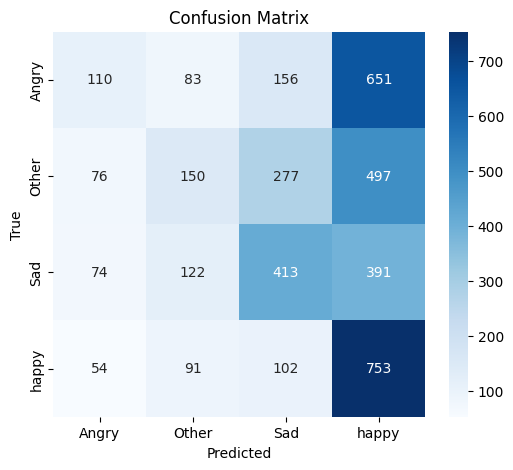

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

model = load_model('/content/ResNet_Feature_Classifier.h5')

# Predict
y_pred = model.predict(X_ext)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_ext_enc, axis=1)

# Report
print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
